# A/B Test Exercise: Spiced search results - changing title color

Comparing two different versions of a website or a search result is a very typical example of A/B testing that you can encounter as a business or marketing data analyst.

In this case we are experimenting with two different colors as presented on pictures below. The visitors were randomly split into two groups where each group has seen only one color. Our task is to establish which color is performing better in terms of the conversion rate (the proportion of how many people clicked on the linked vs the number of people who have seen the search result)

#### Group A

![group_a.png](visitors_group_a.png)

#### Group B

![visitors_group_b.png](visitors_group_b.png)

Below you can see how we can perform such a test using python:

## set environment

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

## load the data

In [2]:
# read the visitors.csv file containing the number of daily visitors for both groups for 30 days
df=pd.read_csv("../data/visitors.csv")


In [22]:
df.head()

,Unnamed: 0,purple,blue
0,0,32.357176,24.010799
1,1,24.045122,27.687188
2,2,37.163535,31.237893
3,3,28.436741,31.229691
4,4,26.397056,30.318586


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  30 non-null     int64  
 1   purple      30 non-null     float64
 2   blue        30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [19]:
# calculate the means of both groups and their difference
conversion_rate_purple_mean=df['purple'].mean()
print(f'average conversation rate:purple: {conversion_rate_purple_mean:.2f}')
conversion_rate_blue_mean=df['blue'].mean()
print(f'average conversation rate blue: {conversion_rate_blue_mean:.2f}')

conversion_rate_diff=conversion_rate_purple_mean-conversion_rate_blue_mean
print(f'conversation_rate_diff: {conversion_rate_diff:.2f}')

std_conversion_rate_purple_mean=df['purple'].std()
print(f'standard deviation of conversion rate purple: {std_conversion_rate_purple_mean:.2f}')
std_conversion_rate_blue_mean=df['blue'].std()
print(f'standard deviation of conversion rate blue: {std_conversion_rate_blue_mean:.2f}')

n_purple=len(df['purple'])
print(f'number of conversion rate purple: {n_purple:.2f}')
n_blue=len(df['blue'])
print(f'number of conversion rate blue: {n_blue:.2f}')

average conversation rate:purple: 30.04
average conversation rate blue: 26.52
conversation_rate_diff: 3.52
standard deviation of conversion rate purple: 5.15
standard deviation of conversion rate blue: 4.50
number of conversion rate purple: 30.00
number of conversion rate blue: 30.00


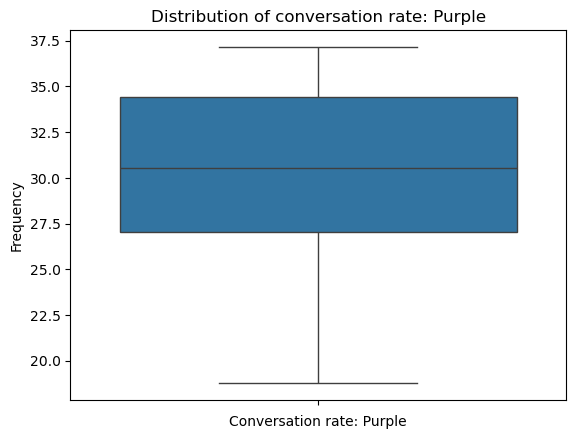

In [5]:
# plot the two groups boxplots
sns.boxplot(df['purple'])
plt.title("Distribution of conversation rate: Purple")
plt.xlabel("Conversation rate: Purple")
plt.ylabel("Frequency")
plt.show()

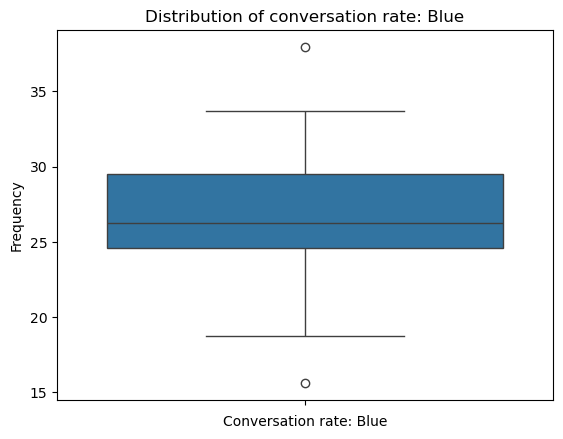

In [6]:
# plot the two groups boxplots
sns.boxplot(df['blue'])
plt.title("Distribution of conversation rate: Blue")
plt.xlabel("Conversation rate: Blue")
plt.ylabel("Frequency")
plt.show()

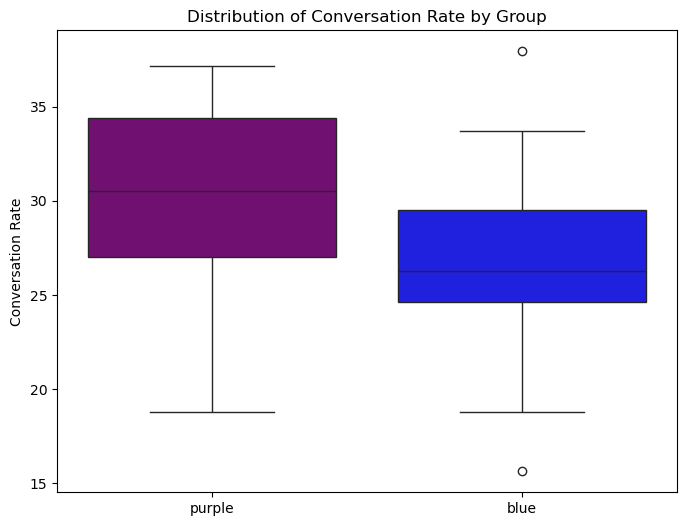

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['purple', 'blue']], palette={'purple':'purple', 'blue':'blue'})
plt.title("Distribution of Conversation Rate by Group")
plt.ylabel("Conversation Rate")
plt.show()



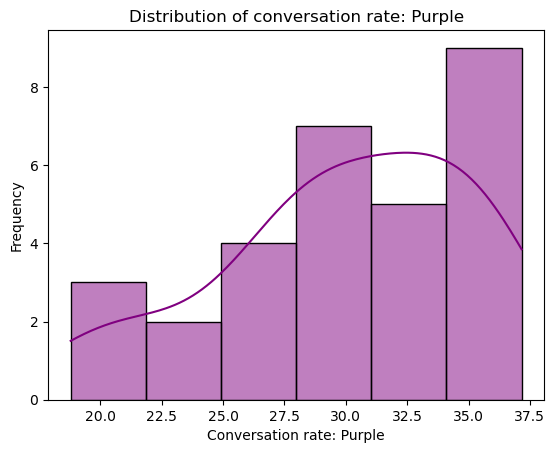

In [8]:
# plot the distributions of both groups using either histograms of displot
sns.histplot(df['purple'], kde=True, color='purple')
plt.title("Distribution of conversation rate: Purple")
plt.xlabel("Conversation rate: Purple")
plt.ylabel("Frequency")
plt.show()


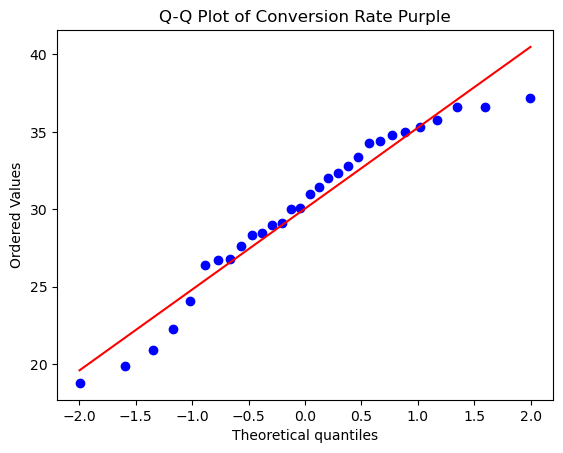

In [9]:
# Q-Q plot
stats.probplot(df['purple'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Conversion Rate Purple")
plt.show()

In [10]:
_, p_value_shapiro = stats.shapiro(df["purple"])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.103


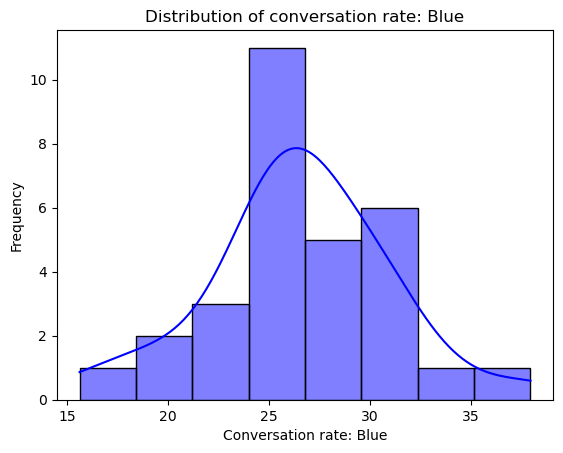

In [11]:
# plot the distributions of both groups using either histograms of displot
sns.histplot(df['blue'], kde=True, color='blue')
plt.title("Distribution of conversation rate: Blue")
plt.xlabel("Conversation rate: Blue")
plt.ylabel("Frequency")
plt.show()

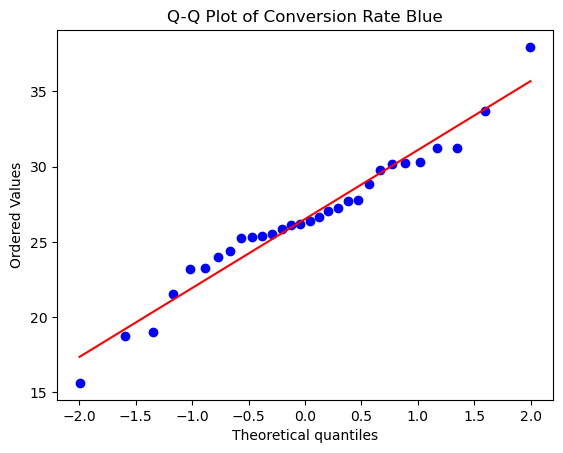

In [12]:
# Q-Q plot
stats.probplot(df['blue'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Conversion Rate Blue")
plt.show()

In [13]:
_, p_value_shapiro = stats.shapiro(df["blue"])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.610


In [14]:
# apply the two-sample t-test on the data. What is the p-value?  Use a significance level of 0.05
import scipy.stats as sps

sample_purple=df['purple']
sample_blue=df['blue']

test_statistic, p_value = sps.ttest_ind(sample_purple, sample_blue)

print(f'test_statistic:{test_statistic:.3f}')
print(f'p_value:{p_value:.3f}')

alpha = 0.05

if p_value < alpha:
    print(f"p = {p_value:.3f} < {alpha}, reject the null hypothesis; there is a significant difference between the two group means.")
else:
    print(f"p = {p_value:.3f} ≥ {alpha}, fail to reject the null hypothesis; the difference between the two group means is not significant.")


test_statistic:2.821
p_value:0.007
p = 0.007 < 0.05, reject the null hypothesis; there is a significant difference between the two group means.


In [25]:
#using t distribution to calculate the range of the group purple
from scipy.stats import t

# t-score for 95% confidence and n-1 degrees of freedom
t_score = t.ppf(0.975, df=n_purple- 1)

# margin of error using t-distribution
margin_of_error = t_score * (std_conversion_rate_purple_mean / np.sqrt(n_purple))

# confidence interval
ci_lower = conversion_rate_purple_mean - margin_of_error
ci_upper = conversion_rate_purple_mean + margin_of_error

print(f'average conversion rate purple: {conversion_rate_purple_mean:.2f}')
print(f"95% Confidence Interval for the Conversion Rate Purple: ({ci_lower:.2f}, {ci_upper:.2f})")

average conversion rate purple: 30.04
95% Confidence Interval for the Conversion Rate Purple: (28.12, 31.96)


In [26]:
#using t distribution to calculate the range of the group blue
from scipy.stats import t

# t-score for 95% confidence and n-1 degrees of freedom
t_score = t.ppf(0.975, df=n_blue- 1)

# margin of error using t-distribution
margin_of_error = t_score * (std_conversion_rate_blue_mean / np.sqrt(n_blue))

# confidence interval
ci_lower = conversion_rate_blue_mean - margin_of_error
ci_upper = conversion_rate_blue_mean + margin_of_error

print(f'average conversion rate blue: {conversion_rate_blue_mean:.2f}')
print(f"95% Confidence Interval for the Conversion Rate Blue: ({ci_lower:.2f}, {ci_upper:.2f})")

average conversion rate blue: 26.52
95% Confidence Interval for the Conversion Rate Blue: (24.84, 28.20)


In [24]:
from scipy.stats import norm

z_score = norm.ppf(0.975) 
margin_of_error = z_score * (std_conversion_rate_purple_mean/ np.sqrt(n_purple))  
ci_lower = conversion_rate_purple_mean - margin_of_error
ci_upper = conversion_rate_purple_mean + margin_of_error

print(f'average conversation rate purple: {conversion_rate_purple_mean:.2f}')
print(f"95% Confidence Interval for the Conversion Rate Purple: ({ci_lower:.2f}, {ci_upper:.2f})")

average conversation rate purple: 30.04
95% Confidence Interval for the Conversion Rate Purple: (28.20, 31.88)


In [23]:
from scipy.stats import norm

z_score = norm.ppf(0.975) 
margin_of_error = z_score * (std_conversion_rate_blue_mean/ np.sqrt(n_blue))  
ci_lower = conversion_rate_blue_mean - margin_of_error
ci_upper = conversion_rate_blue_mean + margin_of_error

print(f'average conversation rate blue {conversion_rate_blue_mean:.2f}')
print(f"95% Confidence Interval for the Conversion Rate Blue: ({ci_lower:.2f}, {ci_upper:.2f})")

average conversation rate blue 26.52
95% Confidence Interval for the Conversion Rate Blue: (24.91, 28.13)


## Step 5: Interpretation in Business Terms

TP-value interpretation:

`p = 0.007 < 0.05 → reject H₀`.

There is statistically significant evidence that the purple title has a better conversion rate.

Confidence interval interpretation:

`Conversion Purple: 30.04~% (95% CI: 28.20%–31.88%)`

`Conversion Blue: ~26.52% (95% CI: 24.91%–28.13%)`

The difference (~3.52%) is positive and consistent with improved performance.

Business implication:

“Our analysis suggests that the purple title performs better than the blue title in terms of conversion rate. 
The improvement in conversion is statistically significant (p = 0.007), with an estimated increase of about 3.52 percentage points in the number of people visiting the SPICED website after doing a google search on 'spiced'.
The overall evidence indicates that the purple color likely leads to higher conversion rate”

### Conclusion: Which group is better ??

since p-value < 0.05, then we conclude that the purple title did indeed cause an increase in the number of people visiting the SPICED website after doing a google search on 'spiced'